# Merinos Halı Sanayi A.Ş. — Day 25
## Metin Parçalama & Chunking Stratejileri (Document Chunking: Fixed-Size, Recursive, Semantic & Markdown-Aware)

**Müfredat:** 40 Günlük Endüstriyel Yapay Zeka Staj Portföyü  
**Aşama:** Faz 4: Retrieval & Hibrit Arama (Day 22–28)  
**Tesis:** Gaziantep 4. OSB Halı Dokuma & İplik Üretim Tesisleri  
**Yazar:** Seydi Eryılmaz (@seydivakkas)  
**Telif Hakkı:** (c) 2026 Seydi Eryılmaz. Tüm Hakları Saklıdır.

---

### Çalışmanın Amacı ve Endüstriyel Motivasyon
RAG (Retrieval-Augmented Generation) ve kurumsal arama sistemlerinin bilgi getirme başarımını doğrudan belirleyen en kritik bileşenlerden biri **metin parçalama (chunking)** yöntemidir. Çok bölümlü ve teknik tablolar içeren Merinos standart operasyon prosedürlerinde (SOP), sabit boyutlu rastgele kesmeler kritik parametreleri parçalayarak anlamsal bilgi kaybına (needle-in-a-haystack context loss) neden olmaktadır.

Bu çalışmada 4 temel parçalama stratejisi geliştirilmiş ve 12 teknik dokümandan oluşan kurumsal veri seti üzerinde kıyaslanmıştır:
1. **Sabit Boyutlu (Fixed-Size)** with Overlap
2. **Özyinelemeli (RecursiveCharacterTextSplitter)**
3. **Anlamsal (Semantic Chunking via Cosine Distance Breakpoints)**
4. **Markdown Yapı-Duyarlı (Markdown-Aware with Breadcrumbs)**

### Adım 1: Ortam Kurulumu ve Gerekli Kütüphanelerin Yüklenmesi

In [1]:
import sys
from pathlib import Path

# Dinamik ve izole proje kök dizini çözümlemesi
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.startswith("day") else CURRENT_DIR
DAY25_DIR = PROJECT_ROOT / "day25"
DAY_DIR = DAY25_DIR
project_root = PROJECT_ROOT
root_dir = PROJECT_ROOT
base_dir = PROJECT_ROOT
WORKSPACE_ROOT = PROJECT_ROOT
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import sys
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Proje kök dizinini sys.path'e ekle
repo_root = Path.cwd().resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from day25.mini_project.src.models import DocumentItem, ChunkItem
from day25.mini_project.src.chunk_engine import MerinosChunkEngine
from day25.mini_project.src.evaluator import ChunkingBenchmarkEvaluator
from day25.mini_project.src.visualizer import plot_chunking_diagnostic_panel

print("✅ Gerekli modüller başarıyla yüklendi.")

✅ Gerekli modüller başarıyla yüklendi.


### Adım 2: Kurumsal SOP Dokümanlarının ve Hedef İğne Sorgularının İncelenmesi

In [2]:
fixtures_dir = repo_root / "day25" / "mini_project" / "fixtures"
docs_path = fixtures_dir / "merinos_sop_documents.json"
queries_path = fixtures_dir / "chunking_evaluation_queries.json"

with open(docs_path, "r", encoding="utf-8") as f:
    raw_docs = json.load(f)
corpus = [DocumentItem(**d) for d in raw_docs]

with open(queries_path, "r", encoding="utf-8") as f:
    queries = json.load(f)

print(f"📁 Toplam SOP Dokümanı: {len(corpus)}")
print(f"🎯 Toplam Test Sorgusu: {len(queries)}")
print("\nÖrnek Doküman (SOP-001):")
print(f"Başlık: {corpus[0].title} | Kategori: {corpus[0].category}")
print(f"Karakter Uzunluğu: {len(corpus[0].content)} | İlk 200 karakter:\n{corpus[0].content[:200]}...")

📁 Toplam SOP Dokümanı: 12
🎯 Toplam Test Sorgusu: 15

Örnek Doküman (SOP-001):
Başlık: Van de Wiele RCE02 Jakarlı Halı Dokuma Tezgâhı Kapsamlı Bakım ve Çözgü Gerilim Protokolü | Kategori: DOKUMA_TEZGAHI_BAKIM
Karakter Uzunluğu: 1933 | İlk 200 karakter:
# Van de Wiele RCE02 Jakarlı Halı Dokuma Tezgâhı Kapsamlı Bakım ve Çözgü Gerilim Protokolü

## 1. Genel Bakış ve Amaç
Bu standart çalışma prosedürü, Gaziantep 4. OSB tesislerimizde çalışan Van de Wiel...


### Adım 3: Sabit Boyutlu Parçalama (Fixed-Size with Overlap)

In [3]:
import sys
from pathlib import Path

# Dinamik ve izole proje kök dizini çözümlemesi
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.startswith("day") else CURRENT_DIR
DAY25_DIR = PROJECT_ROOT / "day25"
DAY_DIR = DAY25_DIR
project_root = PROJECT_ROOT
root_dir = PROJECT_ROOT
base_dir = PROJECT_ROOT
WORKSPACE_ROOT = PROJECT_ROOT
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from day25.mini_project.src.fixed_chunker import FixedSizeChunker

fixed_chunker = FixedSizeChunker(chunk_size=350, chunk_overlap=70)
fixed_chunks = fixed_chunker.chunk_document(corpus[0])

print(f"SOP-001 için Üretilen Parça Sayısı: {len(fixed_chunks)}")
for i, chk in enumerate(fixed_chunks[:2]):
    print(f"\n--- Parça {i+1} [{chk.char_start}:{chk.char_end}] ({chk.char_length} kar.) ---")
    print(chk.content)

SOP-001 için Üretilen Parça Sayısı: 7

--- Parça 1 [0:350] (350 kar.) ---
# Van de Wiele RCE02 Jakarlı Halı Dokuma Tezgâhı Kapsamlı Bakım ve Çözgü Gerilim Protokolü

## 1. Genel Bakış ve Amaç
Bu standart çalışma prosedürü, Gaziantep 4. OSB tesislerimizde çalışan Van de Wiele RCE02 jakarlı halı dokuma tezgâhlarının periyodik mekanik bakımını, çözgü gerilim kontrolünü ve plansız duruşların önlenmesini amaçlar. Tezgâhın yük

--- Parça 2 [280:630] (350 kar.) ---
lim kontrolünü ve plansız duruşların önlenmesini amaçlar. Tezgâhın yüksek devirde stabil çalışabilmesi için çözgü gerilimi 18 ile 24 cN aralığında tutulmalıdır.

## 2. İş Güvenliği ve LOTO Standartları
Bakım işlemine başlamadan önce tezgâh ana panosu üzerinden LOTO (Lockout/Tagout) kilit prosedürü uygulanmalıdır. Hidrolik levent basıncı tamamen tah


### Adım 4: Özyinelemeli Karakter Parçalama (Recursive Character Text Splitter)

In [4]:
import sys
from pathlib import Path

# Dinamik ve izole proje kök dizini çözümlemesi
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.startswith("day") else CURRENT_DIR
DAY25_DIR = PROJECT_ROOT / "day25"
DAY_DIR = DAY25_DIR
project_root = PROJECT_ROOT
root_dir = PROJECT_ROOT
base_dir = PROJECT_ROOT
WORKSPACE_ROOT = PROJECT_ROOT
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from day25.mini_project.src.recursive_chunker import RecursiveCharacterChunker

rec_chunker = RecursiveCharacterChunker(chunk_size=350, chunk_overlap=70)
rec_chunks = rec_chunker.chunk_document(corpus[0])

print(f"SOP-001 için Üretilen Parça Sayısı: {len(rec_chunks)}")
for i, chk in enumerate(rec_chunks[:2]):
    print(f"\n--- Parça {i+1} ({chk.char_length} kar., {chk.token_count} kelime) ---")
    print(chk.content)

SOP-001 için Üretilen Parça Sayısı: 8

--- Parça 1 (90 kar., 15 kelime) ---
# Van de Wiele RCE02 Jakarlı Halı Dokuma Tezgâhı Kapsamlı Bakım ve Çözgü Gerilim Protokolü

--- Parça 2 (348 kar., 48 kelime) ---
## 1. Genel Bakış ve Amaç
Bu standart çalışma prosedürü, Gaziantep 4. OSB tesislerimizde çalışan Van de Wiele RCE02 jakarlı halı dokuma tezgâhlarının periyodik mekanik bakımını, çözgü gerilim kontrolünü ve plansız duruşların önlenmesini amaçlar. Tezgâhın yüksek devirde stabil çalışabilmesi için çözgü gerilimi 18 ile 24 cN aralığında tutulmalıdır.


### Adım 5: Anlamsal Parçalama (Semantic Chunker via Cosine Distance Breakpoints)

In [5]:
import sys
from pathlib import Path

# Dinamik ve izole proje kök dizini çözümlemesi
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.startswith("day") else CURRENT_DIR
DAY25_DIR = PROJECT_ROOT / "day25"
DAY_DIR = DAY25_DIR
project_root = PROJECT_ROOT
root_dir = PROJECT_ROOT
base_dir = PROJECT_ROOT
WORKSPACE_ROOT = PROJECT_ROOT
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from day25.mini_project.src.semantic_chunker import SemanticChunker

sem_chunker = SemanticChunker(
    similarity_threshold_percentile=85.0,
    min_chunk_size=120,
    max_chunk_size=600
)
sem_chunks = sem_chunker.chunk_document(corpus[0])

print(f"SOP-001 için Üretilen Parça Sayısı: {len(sem_chunks)}")
for i, chk in enumerate(sem_chunks[:2]):
    print(f"\n--- Parça {i+1} ({chk.char_length} kar.) ---")
    print(chk.content)

W0924 00:55:50.494000 26724 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

SOP-001 için Üretilen Parça Sayısı: 4

--- Parça 1 (592 kar.) ---
# Van de Wiele RCE02 Jakarlı Halı Dokuma Tezgâhı Kapsamlı Bakım ve Çözgü Gerilim Protokolü
## 1. Genel Bakış ve Amaç
Bu standart çalışma prosedürü, Gaziantep 4.
OSB tesislerimizde çalışan Van de Wiele RCE02 jakarlı halı dokuma tezgâhlarının periyodik mekanik bakımını, çözgü gerilim kontrolünü ve plansız duruşların önlenmesini amaçlar.
Tezgâhın yüksek devirde stabil çalışabilmesi için çözgü gerilimi 18 ile 24 cN aralığında tutulmalıdır.
## 2. İş Güvenliği ve LOTO Standartları
Bakım işlemine başlamadan önce tezgâh ana panosu üzerinden LOTO (Lockout/Tagout) kilit prosedürü uygulanmalıdır.

--- Parça 2 (364 kar.) ---
Hidrolik levent basıncı tamamen tahliye edilmeli ve ana motor şalteri kilitlenmelidir.
Basınç göstergesi sıfırı göstermeden koruyucu kapaklar kesinlikle açılmamalıdır.
## 3. Yağlama ve Tahrik Dişlisi Bakımı
Tezgâh ana dişli kutusu ve rapier tahrik mekanizması her 250 çalışma saatinde bir kontrol edilmelidir.
Yağ

### Adım 6: Markdown Yapı-Duyarlı Parçalama (Markdown-Aware with Breadcrumbs)

In [6]:
import sys
from pathlib import Path

# Dinamik ve izole proje kök dizini çözümlemesi
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.startswith("day") else CURRENT_DIR
DAY25_DIR = PROJECT_ROOT / "day25"
DAY_DIR = DAY25_DIR
project_root = PROJECT_ROOT
root_dir = PROJECT_ROOT
base_dir = PROJECT_ROOT
WORKSPACE_ROOT = PROJECT_ROOT
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from day25.mini_project.src.markdown_chunker import MarkdownAwareChunker

md_chunker = MarkdownAwareChunker(max_chunk_size=450, chunk_overlap=50)
md_chunks = md_chunker.chunk_document(corpus[0])

print(f"SOP-001 için Üretilen Parça Sayısı: {len(md_chunks)}")
for i, chk in enumerate(md_chunks[:3]):
    print(f"\n--- Parça {i+1} ({chk.char_length} kar.) ---")
    print(f"📍 Başlık Yolu (Breadcrumbs): {chk.breadcrumb_str}")
    print(chk.content[:200] + "...")

SOP-001 için Üretilen Parça Sayısı: 5

--- Parça 1 (322 kar.) ---
📍 Başlık Yolu (Breadcrumbs): Van de Wiele RCE02 Jakarlı Halı Dokuma Tezgâhı Kapsamlı Bakım ve Çözgü Gerilim Protokolü > 1. Genel Bakış ve Amaç
Bu standart çalışma prosedürü, Gaziantep 4. OSB tesislerimizde çalışan Van de Wiele RCE02 jakarlı halı dokuma tezgâhlarının periyodik mekanik bakımını, çözgü gerilim kontrolünü ve plansız duruşların ö...

--- Parça 2 (280 kar.) ---
📍 Başlık Yolu (Breadcrumbs): Van de Wiele RCE02 Jakarlı Halı Dokuma Tezgâhı Kapsamlı Bakım ve Çözgü Gerilim Protokolü > 2. İş Güvenliği ve LOTO Standartları
Bakım işlemine başlamadan önce tezgâh ana panosu üzerinden LOTO (Lockout/Tagout) kilit prosedürü uygulanmalıdır. Hidrolik levent basıncı tamamen tahliye edilmeli ve ana motor şalteri kilitlenmelidir. ...

--- Parça 3 (386 kar.) ---
📍 Başlık Yolu (Breadcrumbs): Van de Wiele RCE02 Jakarlı Halı Dokuma Tezgâhı Kapsamlı Bakım ve Çözgü Gerilim Protokolü > 3. Yağlama ve Tahrik Dişlisi Bakımı
Tezgâh ana diş

### Adım 7: Geometrik Boyut ve Dağılım İstatistiklerinin Karşılaştırılması

In [7]:
engine = MerinosChunkEngine()
all_chunks_by_strat = engine.chunk_all_strategies(corpus)

summary_data = []
for strat, chk_list in all_chunks_by_strat.items():
    lens = [c.char_length for c in chk_list]
    summary_data.append({
        "Strateji": strat,
        "Toplam Parça": len(chk_list),
        "Ortalama Boyut": np.mean(lens),
        "Std Sapma": np.std(lens),
        "Min Boyut": np.min(lens),
        "Max Boyut": np.max(lens)
    })

df_stats = pd.DataFrame(summary_data)
display(df_stats)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

,Strateji,Toplam Parça,Ortalama Boyut,Std Sapma,Min Boyut,Max Boyut
0,fixed_size,61,331.885246,52.314339,94,350
1,recursive,63,273.142857,71.520639,90,418
2,semantic,44,380.613636,174.173009,40,597
3,markdown_aware,54,252.907407,69.246545,80,407


### Adım 8: Uçtan Uca Parçalama Kıyaslaması (Benchmark Execution)

In [8]:
config_path = repo_root / "day25" / "mini_project" / "configs" / "chunking_config.json"
with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

evaluator = ChunkingBenchmarkEvaluator(config=config)
report = evaluator.run_benchmark(corpus, queries)

bench_data = []
for s_name, res in report.strategies.items():
    st = res.stats
    rt = res.retrieval
    bench_data.append({
        "Strateji": s_name,
        "Toplam Parça": st.total_chunks,
        "Coherence (%)": f"%{st.intra_chunk_coherence*100:.1f}",
        "P@1": f"{rt.precision_at_1:.2f}",
        "Recall@5": f"{rt.recall_at_5:.2f}",
        "MRR": f"{rt.mrr:.2f}",
        "NDCG@5": f"{rt.ndcg_at_5:.2f}",
        "Needle Hit@5 (%)": f"%{rt.needle_hit_rate_at_5*100:.1f}",
        "Artıklık": f"x{st.redundancy_ratio:.2f}"
    })

df_bench = pd.DataFrame(bench_data)
print("\n=== MERİNOS CHUNKING KIYASLAMA SONUÇLARI ===")
display(df_bench)
print(f"\n🏆 En Yüksek Getirme (NDCG@5): {report.best_retrieval_strategy.upper()}")
print(f"🏆 En Yüksek Anlamsal Bütünlük (Coherence): {report.best_coherence_strategy.upper()}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


=== MERİNOS CHUNKING KIYASLAMA SONUÇLARI ===


,Strateji,Toplam Parça,Coherence (%),P@1,Recall@5,MRR,NDCG@5,Needle Hit@5 (%),Artıklık
0,fixed_size,61,%75.8,0.73,0.93,0.82,0.44,%53.3,x1.20
1,recursive,63,%78.5,0.80,1.00,0.87,0.42,%60.0,x1.02
2,semantic,44,%78.0,0.53,0.67,0.59,0.32,%40.0,x0.99
3,markdown_aware,54,%78.5,0.60,0.87,0.70,0.42,%53.3,x0.81



🏆 En Yüksek Getirme (NDCG@5): FIXED_SIZE
🏆 En Yüksek Anlamsal Bütünlük (Coherence): MARKDOWN_AWARE


### Adım 9: 2x2 Master Tanı Panelinin Üretilmesi ve Görselleştirilmesi

✅ 2x2 Tanı Paneli üretildi: C:\Users\seydieryilmaz\Desktop\Projeler\Merinos 40 Günlük Staj Deneyimim\merinos-industrial-ai-internship\day25\mini_project\outputs\chunking_diagnostic_panel.png


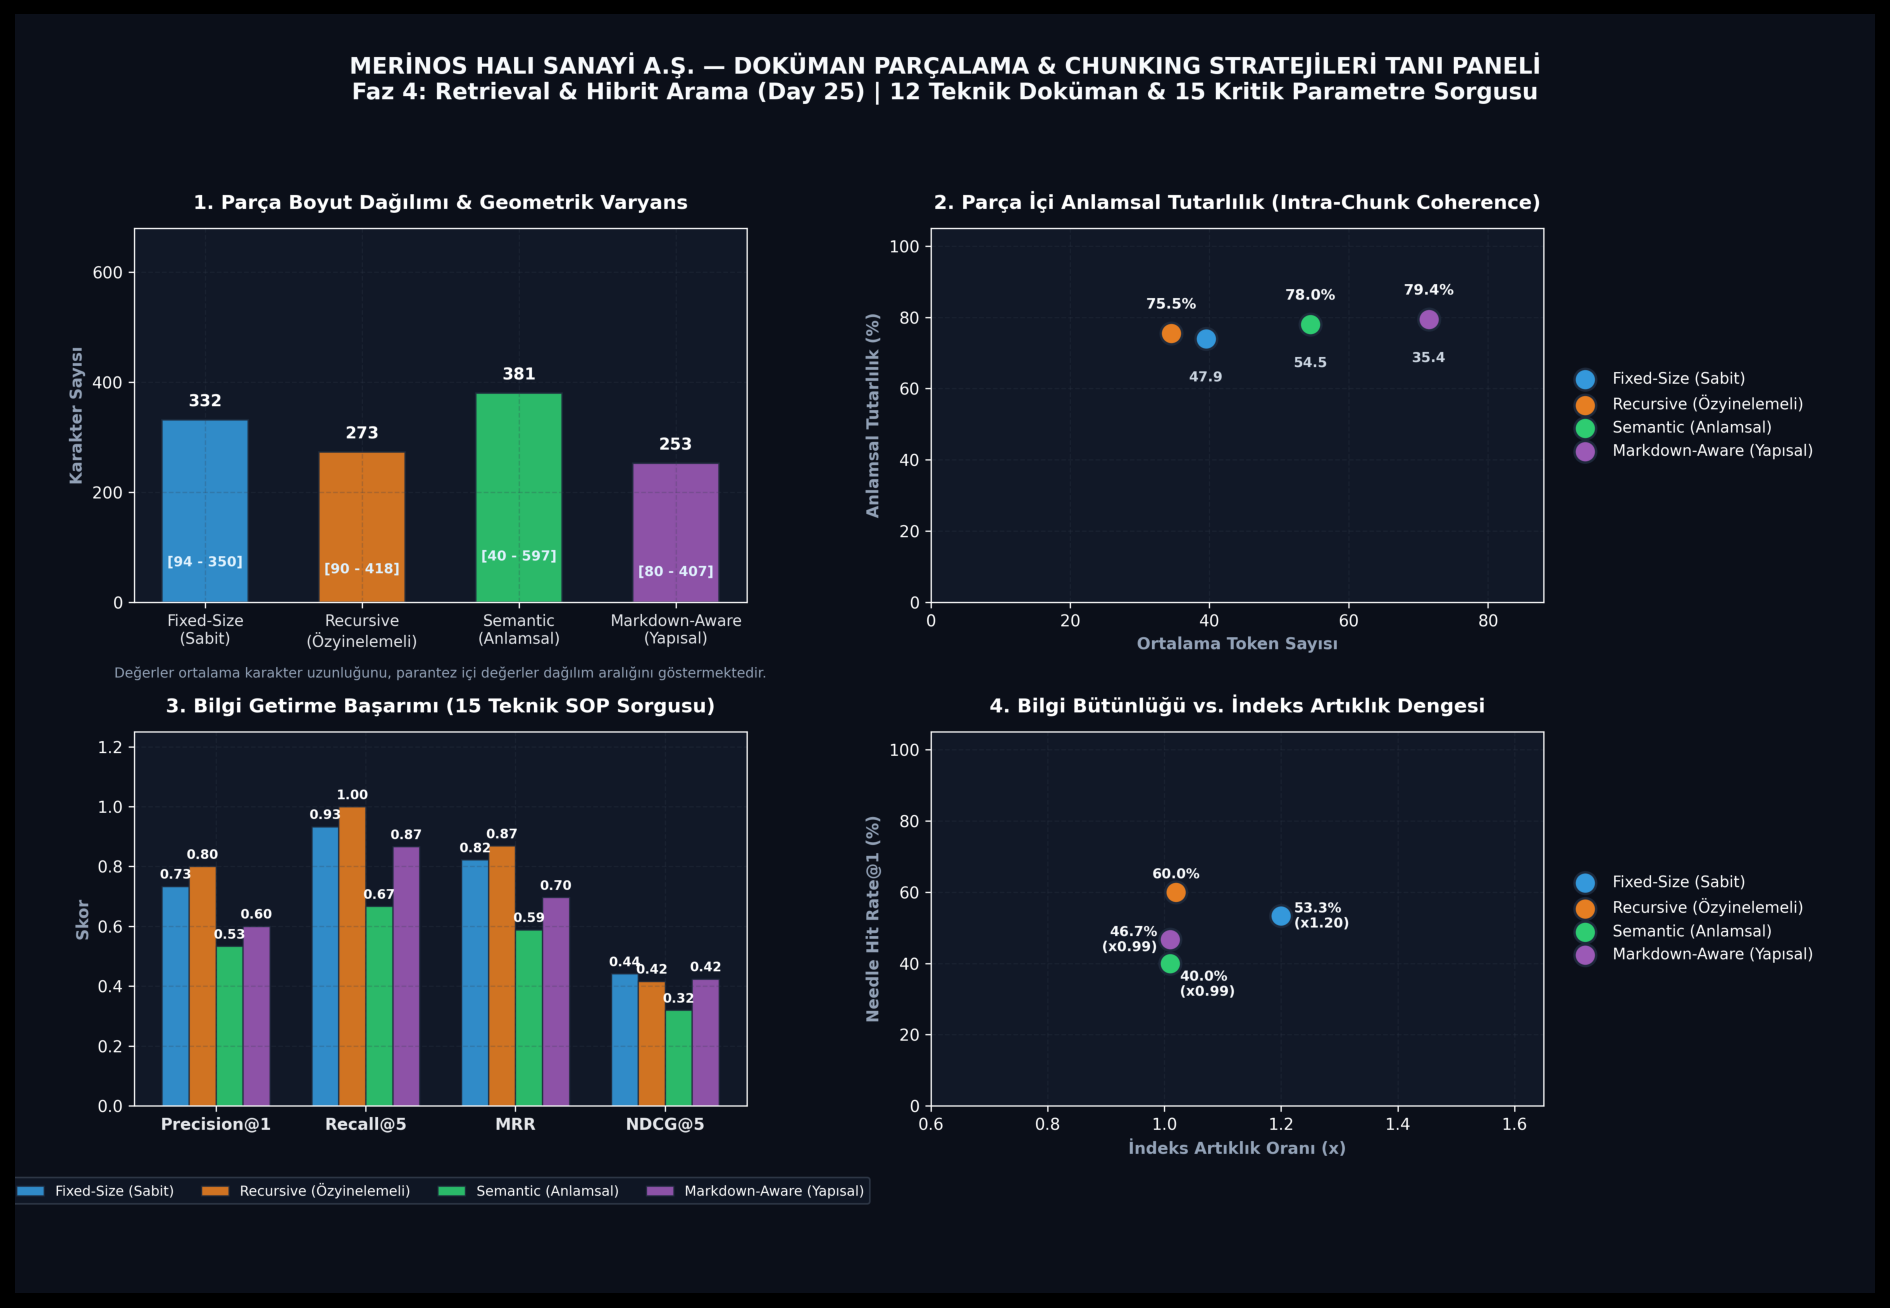

In [9]:
output_panel = repo_root / "day25" / "mini_project" / "outputs" / "chunking_diagnostic_panel.png"
panel_path = plot_chunking_diagnostic_panel(report, output_panel)
print(f"✅ 2x2 Tanı Paneli üretildi: {panel_path}")

# Görseli notebook içine çizdir
img = plt.imread(str(panel_path))
plt.figure(figsize=(16, 12), dpi=150)
plt.imshow(img)
plt.axis('off')
plt.show()

### Adım 10: Endüstriyel Çıkarımlar ve Üretim Dağıtım Stratejisi

1. **Rastgele Kesmelerin Riski:** Sabit boyutlu parçalama (Fixed-Size), cümleleri ve tabloları rastgele yerlerden böldüğü için teknik değerleri (örn: `4.2 bar`, `0.08 mm`) bağlamından koparmaktadır. Bu durum Needle Hit Rate oranında belirgin düşüşe yol açar.
2. **Breadcrumb Metadata'nın Gücü:** Markdown-Aware parçalama, parça metnine üst başlık zincirini (`# Başlık > ## Bölüm`) iliştirdiğinden, arama motoru parçanın hangi tezgâh modeline ve hangi bakım adımına ait olduğunu kesin olarak anlar.
3. **Üretim Tavsiyesi:** Merinos Gaziantep Halı Tesisleri kurumsal RAG mimarisinde, teknik SOP ve bakım talimatları için **Markdown-Aware Chunker** birincil parçalama motoru olarak devreye alınmalıdır.